In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("faizalkarim/flood-area-segmentation")

print("Path to dataset files:", path)

100%|██████████| 107M/107M [00:00<00:00, 138MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1


In [2]:
!ls /kaggle/input/flood-area-segmentation/Mask | head -5

ls: cannot access '/kaggle/input/flood-area-segmentation/Mask': No such file or directory


In [3]:
from torchvision.io.image import decode_image
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
from torchvision.transforms.functional import to_pil_image
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch

import cv2
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import random

In [5]:
img = decode_image("/root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/Image/1079.jpg")

# Step 1: Initialize model with the best available weights
weights = DeepLabV3_ResNet50_Weights.DEFAULT
model = deeplabv3_resnet50(weights=weights)
model.eval()

# Step 2: Initialize the inference transforms
preprocess = weights.transforms()

# Step 3: Apply inference preprocessing transforms
batch = preprocess(img).unsqueeze(0)

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to /root/.cache/torch/hub/checkpoints/deeplabv3_resnet50_coco-cd0a2569.pth
100%|██████████| 161M/161M [00:01<00:00, 165MB/s]


In [ ]:
# Step 4: Use the model and visualize the prediction
prediction = model(batch)["out"]
normalized_masks = prediction.softmax(dim=1)
class_to_idx = {cls: idx for (idx, cls) in enumerate(weights.meta["categories"])}

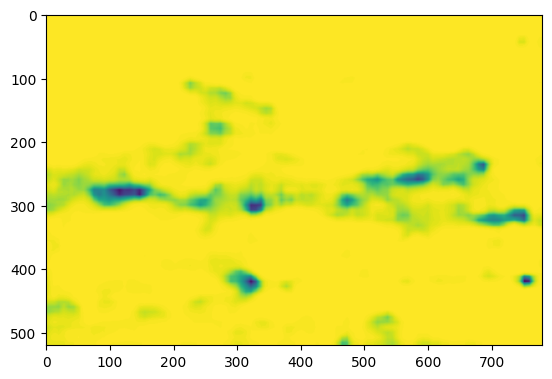

In [ ]:
mask = normalized_masks[0, class_to_idx["__background__"]]

plt.imshow(to_pil_image(mask))

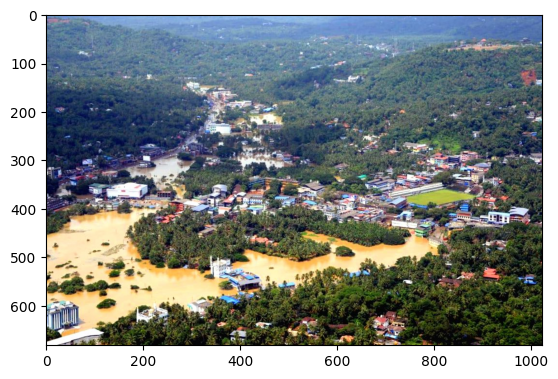

In [ ]:
plt.imshow(img.numpy().transpose(1, 2, 0))

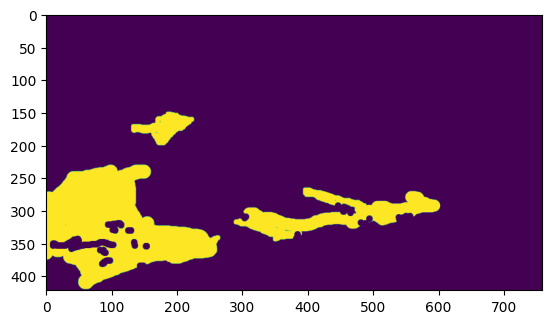

In [ ]:
plt.imshow(decode_image("/kaggle/input/flood-area-segmentation/Mask/1079.png").numpy().transpose(1, 2, 0))

## Cut images to size 224

In [6]:
def from_path_to_patcehs(img_path, mask_path, tile_size = 256, overlap = 15):
    count = 0
    imgs = []
    masks = []

    img = plt.imread(img_path)
    mask = plt.imread(mask_path)

    if mask.shape[1] != img.shape[1] or mask.shape[0] != img.shape[0]:
        return 0, 0, 0

    left_origin_pixel, bottom_origin_pixel = 0, 0
    right_origin_pixel, top_origin_pixel = (img.shape[0], img.shape[1])

    x_shape = int(right_origin_pixel - left_origin_pixel)
    y_shape = int(top_origin_pixel - bottom_origin_pixel)

    x_len_tiles = (x_shape//tile_size > 0) + \
    (x_shape-tile_size)//(tile_size-overlap) + \
    ((x_shape-tile_size)%(tile_size-overlap) > 0)

    y_len_tiles = (y_shape//tile_size > 0) + \
    (y_shape-tile_size)//(tile_size-overlap) + \
    ((y_shape-tile_size)%(tile_size-overlap) > 0)

    for i in range(x_len_tiles):
        for j in range(y_len_tiles):

            right_pixel = left_origin_pixel + min(x_shape, (i+1)*tile_size - i*overlap)
            left_pixel = right_pixel - tile_size

            top_pixel = bottom_origin_pixel + min(y_shape, (j+1)*tile_size - j*overlap)
            bottom_pixel = top_pixel - tile_size

            left, right = left_pixel - left_origin_pixel, left_pixel - left_origin_pixel + tile_size
            bottom, top = bottom_pixel - bottom_origin_pixel, bottom_pixel - bottom_origin_pixel + tile_size

            w = img[bottom:top, left:right, :3]
            w_mask = mask[bottom:top, left:right]

            if w.shape[0] == tile_size and w.shape[1] == tile_size:
                imgs.append(w)
                masks.append(w_mask)
                count += 1

    return imgs, masks, count

In [13]:
images = glob("/root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/Image/*.jpg")

In [ ]:
img_path = images[0]
mask_path = img_path.replace("/Image/", "/Mask/").replace(".jpg", ".png")

imgs, masks, count = from_path_to_patcehs(img_path, mask_path, tile_size = 256)

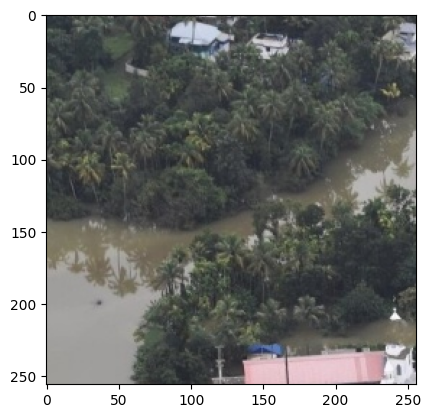

In [ ]:
plt.imshow(imgs[0])

In [8]:
!mkdir Image
!mkdir Mask

In [14]:
from multiprocessing import Pool

def cut_and_save_images(img_path):
    mask_path = img_path.replace("/Image/", "/Mask/").replace(".jpg", ".png")
    imgs, masks, count = from_path_to_patcehs(img_path, mask_path, tile_size = 256)
    if imgs == 0:
        print(f"wrong mask shape {img_path}")
    else:
        for i in range(len(imgs)):
            im_path = img_path.replace("/root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/", "").replace(".jpg", f"_{i}.jpg")
            m_path = im_path.replace("Image/", "Mask/").replace(".jpg", ".png")
            plt.imsave(im_path, imgs[i])
            cv2.imwrite(m_path, masks[i].astype('uint8') * 255)

with Pool(processes=2) as p, tqdm(total=len(images)) as pbar:
        for result in p.imap(cut_and_save_images, images):
            pbar.update()
            pbar.refresh()

  1%|▏         | 4/290 [00:00<00:15, 18.84it/s]

wrong mask shape /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/Image/14.jpg


 35%|███▌      | 102/290 [00:03<00:05, 33.34it/s]

wrong mask shape /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/Image/15.jpg


 40%|███▉      | 115/290 [00:03<00:04, 35.12it/s]

...

 83%|████████▎ | 240/290 [00:13<00:02, 24.07it/s]

wrong mask shape /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/Image/3059.jpg


 85%|████████▍ | 246/290 [00:13<00:02, 21.04it/s]

wrong mask shape /root/.cache/kagglehub/datasets/faizalkarim/flood-area-segmentation/versions/1/Image/2053.jpg


100%|██████████| 290/290 [00:15<00:00, 18.92it/s]


In [15]:
cropped_images = glob("Image/*")

In [16]:
len(cropped_images)

4204

In [17]:
def draw_mask(image, mask_generated) :
  masked_image = image.copy()

  masked_image = np.where(mask_generated,
                          np.array([0,255,0], dtype='uint8'),
                          masked_image)

  masked_image = masked_image

  return cv2.addWeighted(image, 0.3, masked_image, 0.7, 0)

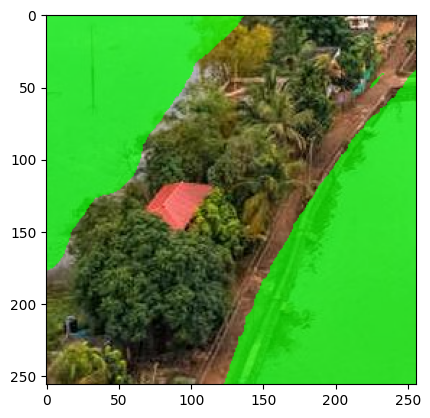

In [18]:
n = 1

image = plt.imread(cropped_images[n])
mask = plt.imread(cropped_images[n].replace("Image/", "Mask/").replace(".jpg", ".png"))
segmented_image = draw_mask(image, np.expand_dims(mask, 2))
plt.imshow(segmented_image)

## Dataset

In [19]:
class CustomDataset(Dataset):
    def __init__(self, images_paths, transform=None):
        self.transform = transform
        self.image_paths = images_paths

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path)[..., ::-1] / 255
        image = image.astype(np.float32)
        mask_path = img_path.replace("Image/", "Mask/").replace(".jpg", ".png")
        mask = cv2.imread(mask_path)[..., 0] / 255
        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed["image"]
            mask = transformed["mask"]
        return image, torch.unsqueeze(mask, 0)

In [20]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
import cv2

train_transform = A.Compose(
    [
        A.Resize(256, 256),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.2),
        # A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(p=1.0)
    ]
)

val_transform = A.Compose(
    [
        A.Resize(256, 256),
        # A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2()
    ]
)

test_transform = A.Compose(
    [
        # A.Resize(256, 256),
        ToTensorV2()
    ]
)

In [21]:
random.seed(10)

In [22]:
len(images)

290

In [23]:
random.shuffle(images)
train_images = images[:int(len(images) * 0.95)]
val_images = images[int(len(images) * 0.95):]

In [24]:
len(train_images)

275

In [25]:
len(val_images)

15

In [26]:
train_images = [x.split("/")[-1] for x in train_images]
val_images = [x.split("/")[-1] for x in val_images]

In [27]:
train_images_paths = []
for img_name in train_images:
    x = img_name.split(".")[0]
    train_images_paths.extend(glob(f"Image/{x}*.jpg"))

In [28]:
val_images_paths = []
for img_name in val_images:
    x = img_name.split(".")[0]
    val_images_paths.extend(glob(f"Image/{x}*.jpg"))

In [29]:
train_dataset = CustomDataset(train_images_paths, train_transform)
val_dataset = CustomDataset(val_images_paths, val_transform)
test_dataset = CustomDataset(val_images_paths, test_transform)

In [30]:
img, mask = test_dataset[0]

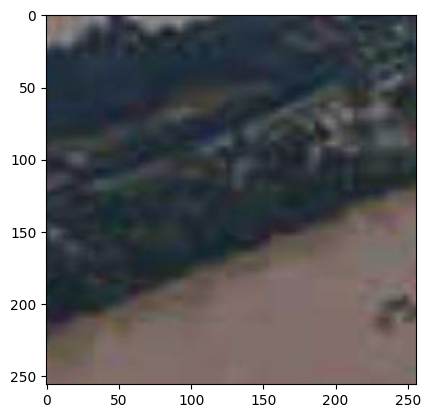

In [31]:
plt.imshow(img.numpy().transpose(1, 2, 0))

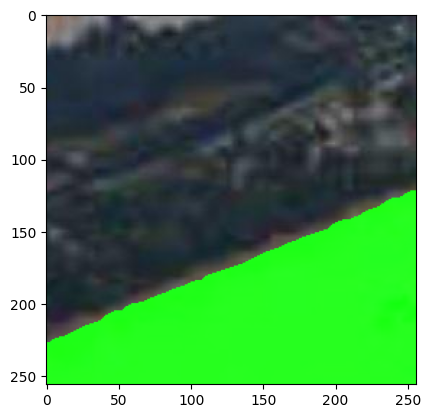

In [32]:
segmented_image = draw_mask(img.numpy().transpose(1, 2, 0), mask.numpy().transpose(1, 2, 0))
plt.imshow(segmented_image)

In [33]:
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=1, drop_last=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=1, drop_last=True)

## Zero-shot methods

In [ ]:
# SEEM
!git clone https://github.com/UX-Decoder/Segment-Everything-Everywhere-All-At-Once.git

Cloning into 'Segment-Everything-Everywhere-All-At-Once'...
remote: Enumerating objects: 1127, done.
remote: Counting objects: 100% (357/357), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 1127 (delta 297), reused 278 (delta 278), pack-reused 770 (from 2)
Receiving objects: 100% (1127/1127), 303.82 MiB | 22.04 MiB/s, done.
Resolving deltas: 100% (492/492), done.


rm numpy version from requirements

In [ ]:
!pip install -r /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 4.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.5/121.5 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 63.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.3/278.3 kB 21.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 867.3/867.3 kB 55.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 773.5 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.0 MB/s eta 0:00:00
  Preparing metad

In [ ]:
!pip install -r /content/Segment-Everything-Everywhere-All-At-Once/assets/requirements/requirements_custom.txt

  Cloning https://github.com/arogozhnikov/einops.git to /tmp/pip-req-build-u968qy4e
  Running command git clone --filter=blob:none --quiet https://github.com/arogozhnikov/einops.git /tmp/pip-req-build-u968qy4e
  Resolved https://github.com/arogozhnikov/einops.git to commit 2d12427a70b673c493044a8a7acfbb4719537e00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/MaureenZOU/detectron2-xyz.git to /tmp/pip-req-build-4g0qrqcd
  Running command git clone --filter=blob:none --quiet https://github.com/MaureenZOU/detectron2-xyz.git /tmp/pip-req-build-4g0qrqcd
  Resolved https://github.com/MaureenZOU/detectron2-xyz.git to commit 42121d75e10d9f858f3a91b6a39f5722c02868f0
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/openai/whisper.git to /tmp/pip-req-build-n5ey3x_t
  Running command git clone --filter=blob:none --quiet https://github.com/openai/whisper.git /tmp

In [ ]:
import os
import warnings
import PIL
from PIL import Image
from typing import TYPE_CHECKING, Any, Callable, Dict, List, Optional, Tuple

import gradio as gr
import torch
import argparse
import whisper
import numpy as np

import sys
sys.path.append('/content/Segment-Everything-Everywhere-All-At-Once/')

from gradio import processing_utils
# from modeling.BaseModel import BaseModel
from modeling import build_model
from utils.distributed import init_distributed
from utils.arguments import load_opt_from_config_files
from utils.constants import COCO_PANOPTIC_CLASSES

from demo.seem.tasks import *

AttributeError: partially initialized module 'jax' has no attribute 'version' (most likely due to a circular import)

In [ ]:
opt = load_opt_from_config_files(["Segment-Everything-Everywhere-All-At-Once/configs/seem/focalt_unicl_lang_demo.yaml"])
opt = init_distributed(opt)

NameError: name 'load_opt_from_config_files' is not defined

In [ ]:
os.system("wget {}".format("https://huggingface.co/xdecoder/SEEM/resolve/main/seem_focalt_v0.pt"))
# os.system("wget {}".format("https://huggingface.co/xdecoder/SEEM/resolve/main/seem_focall_v0.pt"))

pretrained_pth = "seem_focalt_v0.pt"
cur_model = 'Focal-T'

model = BaseModel(opt, build_model(opt)).from_pretrained(pretrained_pth).eval().cuda()
with torch.no_grad():
    model.model.sem_seg_head.predictor.lang_encoder.get_text_embeddings(COCO_PANOPTIC_CLASSES + ["background"], is_eval=True)

In [ ]:
import cv2
image = cv2.imread("/content/img-flood.jpeg")

In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from utils.visualizer import Visualizer
from detectron2.utils.colormap import random_color
from detectron2.data import MetadataCatalog
from detectron2.structures import BitMasks
from modeling.language.loss import vl_similarity
from utils.constants import COCO_PANOPTIC_CLASSES
from detectron2.data.datasets.builtin_meta import COCO_CATEGORIES

import cv2
import os
import glob
import subprocess
from PIL import Image
import random

# t = []
# t.append(transforms.Resize(512, interpolation=Image.BICUBIC))
# transform = transforms.Compose(t)
metadata = MetadataCatalog.get('coco_2017_train_panoptic')
all_classes = [name.replace('-other','').replace('-merged','') for name in COCO_PANOPTIC_CLASSES] + ["others"]
colors_list = [(np.array(color['color'])/255).tolist() for color in COCO_CATEGORIES] + [[1, 1, 1]]

In [ ]:
images = torch.from_numpy(image[..., ::-1].copy()).permute(2,0,1).cuda()

In [ ]:
tasks = ["Panoptic"]
# inistalize task
model.model.task_switch['spatial'] = False
model.model.task_switch['visual'] = False
model.model.task_switch['grounding'] = False
model.model.task_switch['audio'] = False

data = {"image": images, "height": 256, "width": 256}

batch_inputs = [data]
if 'Panoptic' in tasks:
    model.model.metadata = metadata
    results = model.model.evaluate(batch_inputs)
    pano_seg = results[-1]['panoptic_seg'][0]
    pano_seg_info = results[-1]['panoptic_seg'][1]

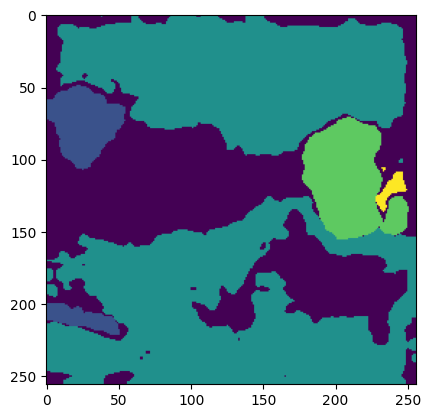

In [ ]:
import matplotlib.pyplot as plt

mask = pano_seg.cpu().detach().numpy()
plt.imshow(mask)

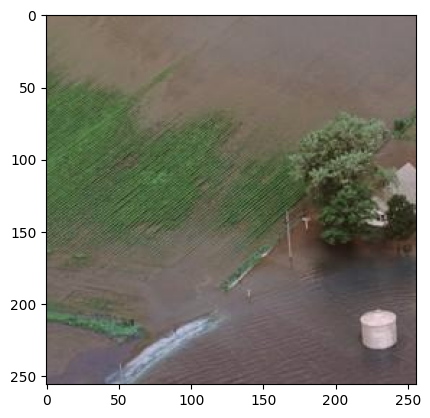

In [ ]:
plt.imshow(image)

In [ ]:
visual = Visualizer(image[..., ::-1], metadata=metadata)
demo = visual.draw_panoptic_seg(pano_seg.cpu(), pano_seg_info) # rgb Image
res = demo.get_image()
vis = Image.fromarray(res)

/content/Segment-Everything-Everywhere-All-At-Once/utils/visualizer.py:218: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  yield (self._seg == sid).numpy().astype(np.bool), sinfo


AttributeError: module 'numpy' has no attribute 'bool'.
`np.bool` was a deprecated alias for the builtin `bool`. To avoid this error in existing code, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

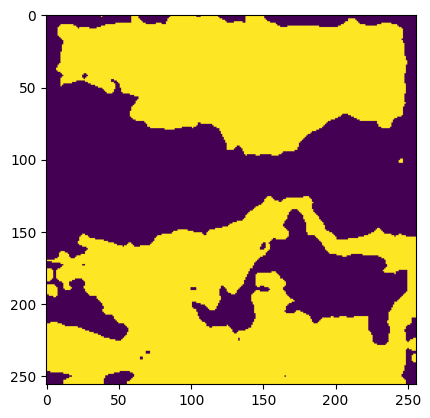

In [ ]:
plt.imshow(mask == 2)

In [ ]:
def get_seem_prediction(image):
    images = torch.from_numpy(image.copy()).cuda()
    tasks = ["Panoptic"]
    # inistalize task
    model.model.task_switch['spatial'] = False
    model.model.task_switch['visual'] = False
    model.model.task_switch['grounding'] = False
    model.model.task_switch['audio'] = False

    data = {"image": images, "height": 256, "width": 256}

    batch_inputs = [data]
    if 'Panoptic' in tasks:
        model.model.metadata = metadata
        results = model.model.evaluate(batch_inputs)
        pano_seg = results[-1]['panoptic_seg'][0]
        pano_seg_info = results[-1]['panoptic_seg'][1]

    mask = pano_seg.cpu().detach().numpy()

    return mask

## Metrics

In [ ]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 58.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 67.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.1 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

In [ ]:
from torchmetrics import JaccardIndex

img, target = test_dataset[0]
pred = torch.ones((1, 256, 256))

jaccard = JaccardIndex(task='multiclass', num_classes=2)
jaccard(pred, target) * 2

tensor(0.7779)

In [42]:
def iou_pytorch(outputs: torch.Tensor, labels: torch.Tensor):
    outputs = outputs.squeeze(1).byte()  # BATCH x 1 x H x W => BATCH x H x W
    labels = labels.squeeze(1).byte()
    SMOOTH = 1e-8
    intersection = (outputs & labels).float().sum((1, 2))  # Ноль если if Truth=0 or Prediction=0
    union = (outputs | labels).float().sum((1, 2))         # Ноль если оба равны 0

    iou = (intersection + SMOOTH) / (union + SMOOTH)  # Избегаем 0/0

    return iou

In [ ]:
iou_pytorch(pred, target)

tensor([0.7779])

## Pytorch Lightning

https://github.com/qubvel-org/segmentation_models.pytorch?tab=readme-ov-file#installation

In [ ]:
!pip install pytorch-lightning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.0/823.0 kB 26.0 MB/s eta 0:00:00


In [ ]:
!pip install segmentation-models-pytorch

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.3/121.3 kB 10.8 MB/s eta 0:00:00
  Created wheel for efficientnet-pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=f34da8b4afbb0ebd1cc89c2353e23688796baae364672f62600a89faccd930fc
  Stored in directory: /root/.cache/pip/wheels/8b/6f/9b/231a832f811ab6ebb1b32455b177ffc6b8b1cd8de19de70c09
  Created wheel for pretrainedmodels: filename=pretrainedmodels-0.7.4-py3-none-any.whl size=60945 sha256=3c310a723d2d5f1bff5a92ce7316af62d8b66bb8642c9f84a78438feed734164
  Stored in directory: /root/.cache/pip/wheels/5f/5b/96/fd94bc35962d7c6b699e8814db545155ac91d2b95785e1b035
Successfully built efficientnet-pytorch pretrainedmodels


In [ ]:
import pytorch_lightning as pl
import segmentation_models_pytorch as smp
from torch.optim import lr_scheduler

In [ ]:
class FloodModel(pl.LightningModule):
    def __init__(self, arch, encoder_name, in_channels, out_classes, **kwargs):
        super().__init__()
        self.model = smp.create_model(
            arch,
            encoder_name=encoder_name,
            in_channels=in_channels,
            classes=out_classes,
            **kwargs,
        )
        # preprocessing parameteres for image
        params = smp.encoders.get_preprocessing_params(encoder_name)
        self.register_buffer("std", torch.tensor(params["std"]).view(1, 3, 1, 1))
        self.register_buffer("mean", torch.tensor(params["mean"]).view(1, 3, 1, 1))

        # for image segmentation dice loss could be the best first choice
        # self.loss_fn = smp.losses.DiceLoss(smp.losses.BINARY_MODE, from_logits=True)
        self.loss_fn = torch.nn.BCEWithLogitsLoss()

        # initialize step metics
        self.training_step_outputs = []
        self.validation_step_outputs = []
        self.test_step_outputs = []

    def forward(self, image):
        # normalize image here
        image = (image - self.mean) / self.std
        mask = self.model(image)
        return mask

    def shared_step(self, batch, stage):
        image = batch[0]

        # Shape of the image should be (batch_size, num_channels, height, width)
        # if you work with grayscale images, expand channels dim to have [batch_size, 1, height, width]
        assert image.ndim == 4

        # Check that image dimensions are divisible by 32,
        # encoder and decoder connected by `skip connections` and usually encoder have 5 stages of
        # downsampling by factor 2 (2 ^ 5 = 32); e.g. if we have image with shape 65x65 we will have
        # following shapes of features in encoder and decoder: 84, 42, 21, 10, 5 -> 5, 10, 20, 40, 80
        # and we will get an error trying to concat these features
        h, w = image.shape[2:]
        assert h % 32 == 0 and w % 32 == 0

        mask = batch[1]
        assert mask.ndim == 4

        # Check that mask values in between 0 and 1, NOT 0 and 255 for binary segmentation
        assert mask.max() <= 1.0 and mask.min() >= 0

        logits_mask = self.forward(image)

        # Predicted mask contains logits, and loss_fn param `from_logits` is set to True
        loss = self.loss_fn(logits_mask, mask)

        # Lets compute metrics for some threshold
        # first convert mask values to probabilities, then
        # apply thresholding
        prob_mask = logits_mask.sigmoid()
        pred_mask = (prob_mask > 0.5).float()

        # We will compute IoU metric by two ways
        #   1. dataset-wise
        #   2. image-wise
        # but for now we just compute true positive, false positive, false negative and
        # true negative 'pixels' for each image and class
        # these values will be aggregated in the end of an epoch
        tp, fp, fn, tn = smp.metrics.get_stats(
            pred_mask.long(), mask.long(), mode="binary"
        )
        return {
            "loss": loss,
            "tp": tp,
            "fp": fp,
            "fn": fn,
            "tn": tn,
        }

    def shared_epoch_end(self, outputs, stage):
        # aggregate step metics
        tp = torch.cat([x["tp"] for x in outputs])
        fp = torch.cat([x["fp"] for x in outputs])
        fn = torch.cat([x["fn"] for x in outputs])
        tn = torch.cat([x["tn"] for x in outputs])

        # per image IoU means that we first calculate IoU score for each image
        # and then compute mean over these scores
        per_image_iou = smp.metrics.iou_score(
            tp, fp, fn, tn, reduction="micro-imagewise"
        )

        # dataset IoU means that we aggregate intersection and union over whole dataset
        # and then compute IoU score. The difference between dataset_iou and per_image_iou scores
        # in this particular case will not be much, however for dataset
        # with "empty" images (images without target class) a large gap could be observed.
        # Empty images influence a lot on per_image_iou and much less on dataset_iou.
        dataset_iou = smp.metrics.iou_score(tp, fp, fn, tn, reduction="micro")
        metrics = {
            f"{stage}_per_image_iou": per_image_iou,
            f"{stage}_dataset_iou": dataset_iou,
        }

        self.log_dict(metrics, prog_bar=True)

    def training_step(self, batch, batch_idx):
        train_loss_info = self.shared_step(batch, "train")
        # append the metics of each step to the
        self.training_step_outputs.append(train_loss_info)
        return train_loss_info

    def on_train_epoch_end(self):
        self.shared_epoch_end(self.training_step_outputs, "train")
        # empty set output list
        self.training_step_outputs.clear()
        return

    def validation_step(self, batch, batch_idx):
        valid_loss_info = self.shared_step(batch, "valid")
        self.validation_step_outputs.append(valid_loss_info)
        return valid_loss_info

    def on_validation_epoch_end(self):
        self.shared_epoch_end(self.validation_step_outputs, "valid")
        self.validation_step_outputs.clear()
        return

    def test_step(self, batch, batch_idx):
        test_loss_info = self.shared_step(batch, "test")
        self.test_step_outputs.append(test_loss_info)
        return test_loss_info

    def on_test_epoch_end(self):
        self.shared_epoch_end(self.test_step_outputs, "test")
        # empty set output list
        self.test_step_outputs.clear()
        return

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=2e-4)
        scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=T_MAX, eta_min=1e-5)
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "interval": "step",
                "frequency": 1,
            },
        }
        return

In [ ]:
model = FloodModel("DeepLabV3", "resnet50", in_channels=3, out_classes=1)

In [ ]:
# Some training hyperparameters
EPOCHS = 10
T_MAX = EPOCHS * len(train_dataloader)
OUT_CLASSES = 1

In [ ]:
trainer = pl.Trainer(max_epochs=EPOCHS, log_every_n_steps=1)

trainer.fit(
    model.cuda(),
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

INFO:pytorch_lightning.utilities.rank_zero:You are using the plain ModelCheckpoint callback. Consider using LitModelCheckpoint which with seamless uploading to Model registry.
INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:pytorch_lightning.callbacks.model_summary:
  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | DeepLabV3         | 39.6 M | train
1 | loss_fn | BCEWithLogitsLoss | 0      | train
------------------------------------------------------
39.6 M    Trainable params
0         Non-trainable params
39.6 M    Total params
158.535   Total estimated model params size (MB)
188       Modules in train mode
0         Modules in eval mod

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

In [ ]:
it = iter(train_dataloader)

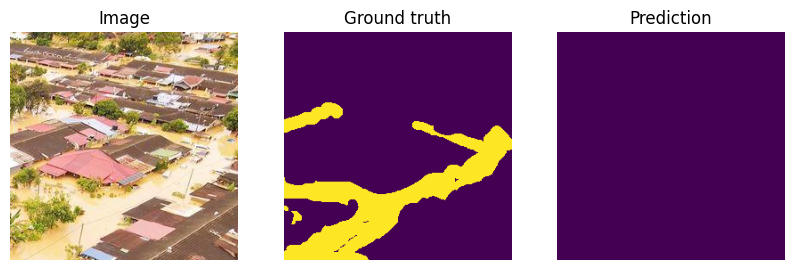

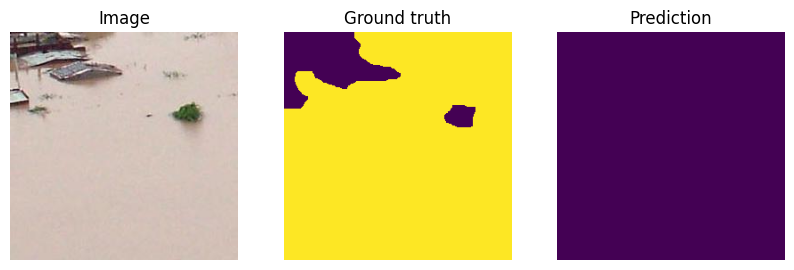

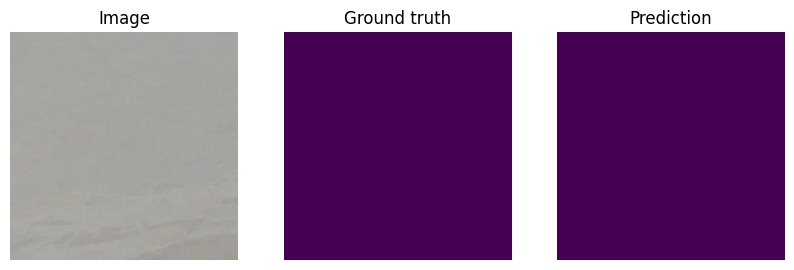

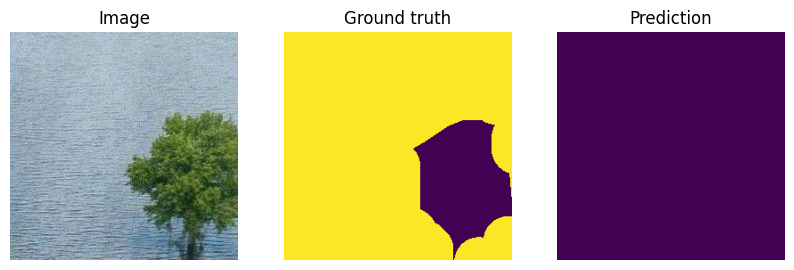

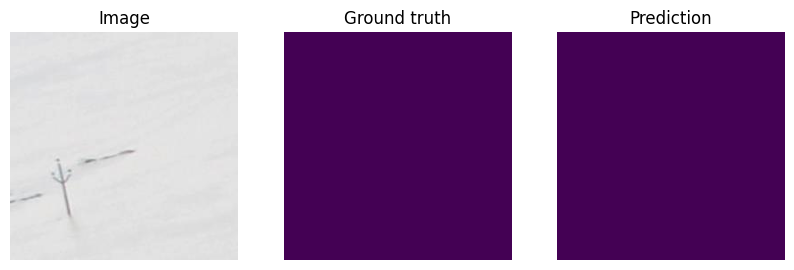

In [ ]:
batch = next(it)
with torch.no_grad():
    model.cuda()
    model.eval()
    logits = model(batch[0].cuda())
pr_masks = logits.sigmoid()
for idx, (image, gt_mask, pr_mask) in enumerate(
    zip(batch[0], batch[1], pr_masks)
):
    if idx <= 4:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.numpy().squeeze())
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.cpu().detach().numpy().squeeze())
        plt.title("Prediction")
        plt.axis("off")
        plt.show()
    else:
        break

In [ ]:
logits.min()

tensor(253.2076, device='cuda:0')

## Pytorch

In [34]:
device = "cuda:0"

In [35]:
from IPython.display import clear_output
from time import time

# цикл обучения
def train(model, opt, loss_fn, epochs, data_tr, data_val, scheduler, path):
    X_val, Y_val = next(iter(data_val))
    X_val = X_val.to(device)
    Y_val = Y_val.to(device)

    train_loss = []
    val_loss = []
    train_score = []
    val_score = []
    for epoch in range(epochs):
        tic = time()
        print('* Epoch %d/%d' % (epoch+1, epochs))

        avg_loss = 0
        avg_train_score = 0
        model.train()  # train mode
        for X_batch, Y_batch in tqdm(data_tr):
            # перенос на device
            X_batch = X_batch.to(device)
            Y_batch = Y_batch.to(device)
            # обнуляем градиент в оптимизаторе
            opt.zero_grad()
            # forward
            with torch.set_grad_enabled(True):
                Y_pred = model(X_batch)["out"]

                avg_train_score += iou_pytorch(Y_pred>0, Y_batch).mean().item()

                loss =  loss_fn(Y_batch, Y_pred)# forward-pass
                loss.backward()  # backward-pass
                opt.step()  # обновление весов

                scheduler.step() # лучше выключить при обучении своей сети без претрейна
            # суммируем лосс чтобы вывести график
            avg_loss += loss / len(data_tr)

        avg_train_score = avg_train_score / len(data_tr)

        train_score.append(avg_train_score)
        train_loss.append(avg_loss)

        toc = time()
        print('loss: %f' % avg_loss)

        avg_val_loss = 0
        avg_val_score = 0
        # промежуточные результаты
        model.eval()  # testing mode
        with torch.no_grad():
            for X_val_batch, Y_val_batch in tqdm(data_val):
                # перенос на device
                X_val_batch = X_val_batch.to(device)
                Y_val_batch = Y_val_batch.to(device)
                # forward
                Y_val_pred = model(X_val_batch)["out"]
                vall_loss =  loss_fn(Y_val_batch, Y_val_pred)# forward-pass
                avg_val_score += iou_pytorch(Y_val_pred >0, Y_val_batch).mean().item()
                # суммируем лосс
                avg_val_loss += vall_loss / len(data_val)

        val_loss.append(avg_val_loss)
        avg_val_score = avg_val_score / len(data_val)
        val_score.append(avg_val_score)

    torch.save(model, path)
    return train_loss, val_loss, train_score, val_score

In [36]:
def predict(model, data):
    model.eval()  # testing mode
    Y_pred = [ X_batch for X_batch, _ in data]
    return np.array(Y_pred)

def score_model(model, metric, data):
    #model.eval()  # testing mode
    scores = 0
    with torch.no_grad():
        for X_batch, Y_label in data:
            Y_pred = model(X_batch.to(device))
            scores += metric(Y_pred["out"]>0, Y_label.to(device)).mean().item()
    return scores/len(data)

In [40]:
def model_scorerer(model_class, path, max_epochs, loss, data_tr, data_val):
    model_name = str(model_class).split()[0][:-1]
    loss_name = "bce"
    title = f"Working with {model_name} and {loss_name}"

    model = model_class.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=200, gamma=0.1)
    train_loss, val_loss, train_score, val_score = \
    train(model, optimizer, loss, max_epochs, data_tr, data_val, scheduler, path)

    # print()
    # visualize(train_loss.cpu().numpy(), val_loss.cpu().numpy(), train_score, val_score, title)

    print(title)
    print(f"validation score: {score_model(model, iou_pytorch, data_val)}")
    return train_loss, val_loss, train_score, val_score, model

In [38]:
bce_loss = torch.nn.BCEWithLogitsLoss()

In [44]:
model.aux_classifier[4] = torch.nn.Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1))
model.classifier[4] = torch.nn.Conv2d(256, 1, kernel_size=(1, 1), stride=(1, 1))

In [45]:
train_loss_unet_bce, val_loss_unet_bce, train_score_unet_bce, val_score_unet_bce, model_unet_bce = \
model_scorerer(model, "deeplabv3_bce.pt", 2, bce_loss, train_dataloader, val_dataloader)

* Epoch 1/2


100%|██████████| 660/660 [13:21<00:00,  1.21s/it]


loss: -0.998716


100%|██████████| 78/78 [00:31<00:00,  2.50it/s]


* Epoch 2/2


100%|██████████| 660/660 [13:24<00:00,  1.22s/it]


loss: -1.255972


100%|██████████| 78/78 [00:31<00:00,  2.51it/s]


Working with DeepLabV3 and bce
validation score: 0.5823434526339556


In [46]:
it = iter(val_dataloader)

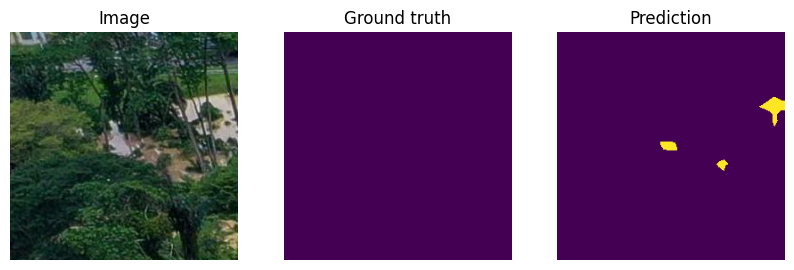

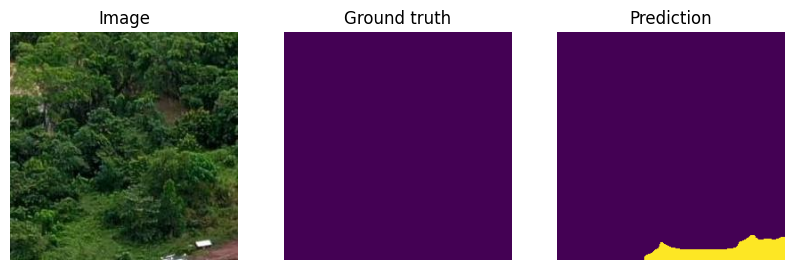

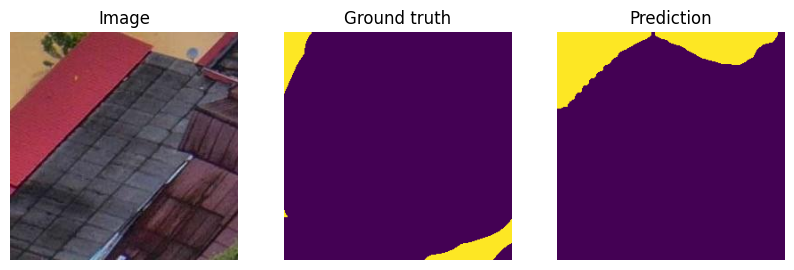

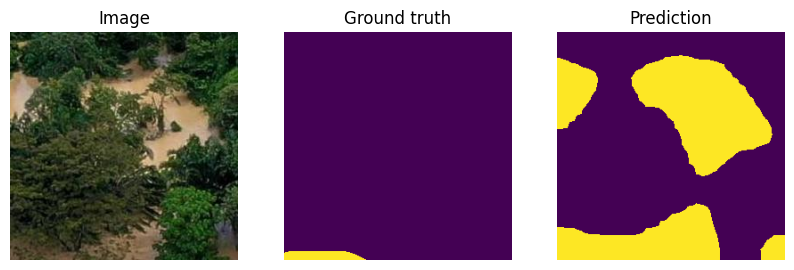

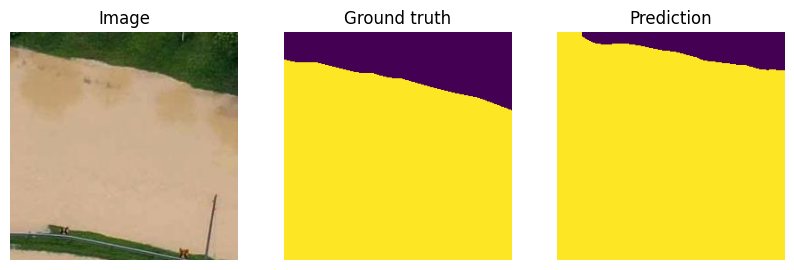

In [49]:
batch = next(it)
with torch.no_grad():
    model.cuda()
    model.eval()
    logits = model(batch[0].cuda())["out"]
pr_masks = logits.sigmoid()
for idx, (image, gt_mask, pr_mask) in enumerate(
    zip(batch[0], batch[1], pr_masks)
):
    if idx <= 4:
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(image.cpu().detach().numpy().transpose(1, 2, 0))
        plt.title("Image")
        plt.axis("off")

        plt.subplot(1, 3, 2)
        plt.imshow(gt_mask.numpy().squeeze())
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(1, 3, 3)
        plt.imshow(pr_mask.cpu().detach().numpy().squeeze() > 0.5)
        plt.title("Prediction")
        plt.axis("off")
        plt.show()
    else:
        break

## Inference

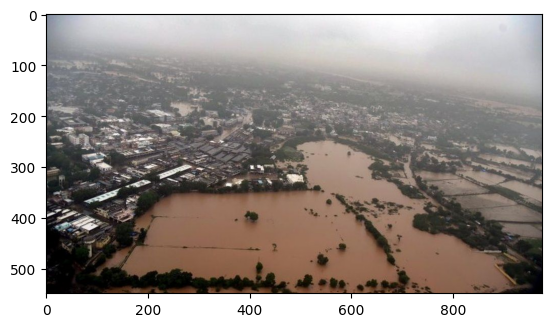

In [69]:
image = cv2.imread(images[1])[..., ::-1]
plt.imshow(image)

In [70]:
i = 0
j = 0
mask = np.zeros_like(image[..., 0]).astype(float)
while i < image.shape[0]:
    j = 0
    while j < image.shape[1]:
        print(i, j)
        img = image[i:min(image.shape[0], i + 256), j:min(image.shape[1], j + 256)]
        img = torch.Tensor((img / 255).transpose(2, 0, 1).copy()).unsqueeze(0)
        with torch.no_grad():
            logits = model(img.cuda())["out"]
        pr_masks = logits.sigmoid()
        mask[i:min(image.shape[0], i + 256), j:min(image.shape[1], j + 256)] += pr_masks.cpu().detach().numpy()[0, 0]
        j += 256
    i += 256

0 0
0 256
0 512
0 768
256 0
256 256
256 512
256 768
512 0
512 256
512 512
512 768


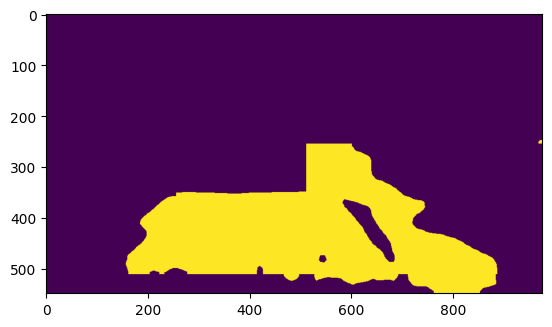

In [71]:
plt.imshow(mask > 0.8)